<a href="https://colab.research.google.com/github/JJsupercoder/GIS-Green-Area-Coverage/blob/main/ConvLSTM_NDVI_Prediction_code.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
import torch, numpy as np

class mapLSTM():
    def __init__(self, dims = (18, 23), lookback = 4, layers = 2, lr = 0.001, dropout = 0.0):
        self.dims = dims
        self.lookback = lookback
        self.lr = lr
        self.model = torch.nn.LSTM(dims[0]*dims[1], dims[0]*dims[1], num_layers = layers, dropout = dropout)
        self.optimizer= torch.optim.Adam(self.model.parameters(), lr=self.lr)

    def forward(self, map_seq):
        input = torch.tensor(map_seq).reshape(-1, self.dims[0]*self.dims[1])
        output = self.model(torch.tensor(map_seq).reshape(-1, self.dims[0]*self.dims[1]))[0][-1]
        return output.reshape(self.dims[0], self.dims[1])

    def train(self, data, epochs = 2000):
        dataTensor = torch.tensor(data)
        meanLoss = torch.tensor(0.)
        for epoch in range(epochs):
            if np.random.random() < 0.4:
                index = len(data) - self.lookback - 1
            else:
                index = np.random.randint(len(data) - self.lookback)
            target = dataTensor[index + self.lookback].reshape(self.dims[0]*self.dims[1])
            pred = self.model((dataTensor[index:index + self.lookback].reshape(-1, self.dims[0]*self.dims[1])))[0][-1]
            loss = torch.nn.functional.l1_loss(pred, target, reduction = 'sum')
            meanLoss += loss
            loss.backward()
            self.optimizer.step()
            self.optimizer.zero_grad()
            if (epoch + 1) % 100 == 0:
                print(f'Epoch {epoch + 1} : {meanLoss.item()/100}')
                meanLoss = torch.tensor(0.)




In [ ]:

data = np.load('ndvi_maps_updated_latest.npy').astype(np.float32)
# np.save( 'train_ndvi.npy', data[:24])
# dataTrain = np.load('train_ndvi.npy')
# np.save( 'test_ndvi.npy', data[24:])
# dataTest = np.load('test_ndvi.npy')

dataTrain = data[20:29]
dataTest = data[25:]
data = data[20:]

In [ ]:
print(data.shape)

(11, 18, 23)


In [ ]:
print(dataTrain.shape)
print(dataTest.shape)

(9, 18, 23)
(6, 18, 23)


In [ ]:
lstm = mapLSTM(lookback = 4, lr = 0.001, layers = 3)
lstm.train(dataTrain, 2000) #3000 epochs

Epoch 100 : 8.608592529296875
Epoch 200 : 5.45666748046875
Epoch 300 : 4.714375305175781
Epoch 400 : 4.674039916992188
Epoch 500 : 2.8777679443359374
Epoch 600 : 2.7917910766601564
Epoch 700 : 2.982181396484375
Epoch 800 : 2.658172912597656
Epoch 900 : 2.77240966796875
Epoch 1000 : 2.6874130249023436
Epoch 1100 : 2.51902099609375
Epoch 1200 : 3.0811190795898438
Epoch 1300 : 2.2327500915527345
Epoch 1400 : 1.8989083862304688
Epoch 1500 : 2.1144654846191404
Epoch 1600 : 1.6254681396484374
Epoch 1700 : 1.28494384765625
Epoch 1800 : 1.185814208984375
Epoch 1900 : 0.8205472564697266
Epoch 2000 : 0.8034349060058594


4
(9, 18, 23)


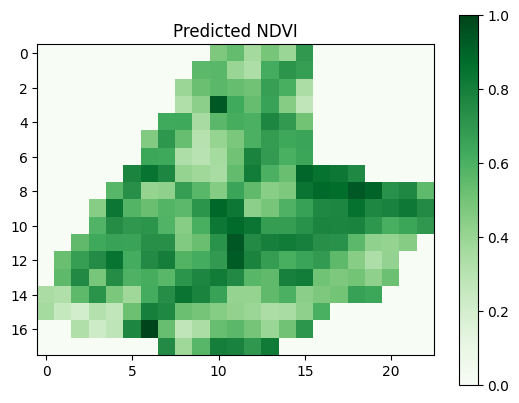

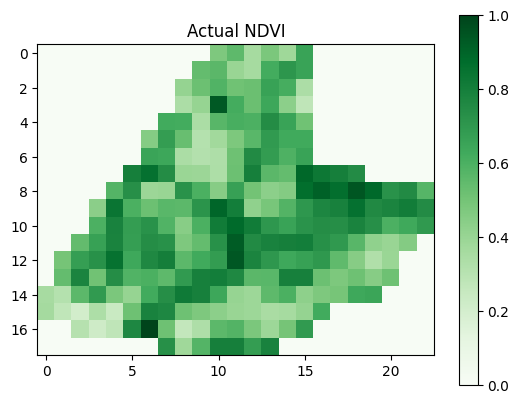

Step: 4
Predicted NDVI Greenery Percentage: 2.4154589371980677 Actual NDVI  Greenery Percentage: 2.4154589371980677


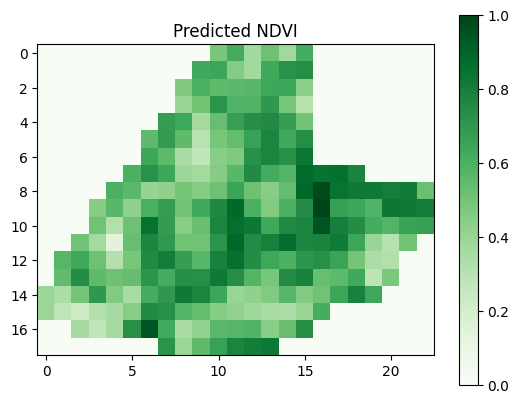

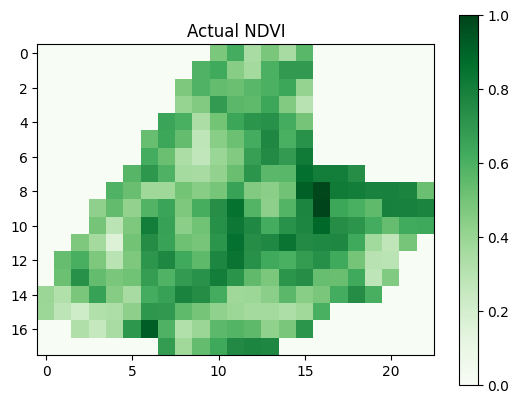

Step: 5
Predicted NDVI Greenery Percentage: 2.4154589371980677 Actual NDVI  Greenery Percentage: 2.657004830917874


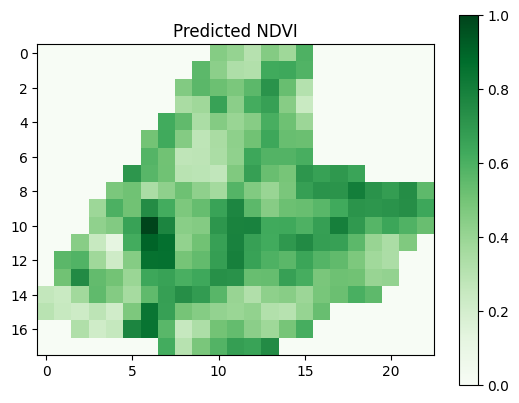

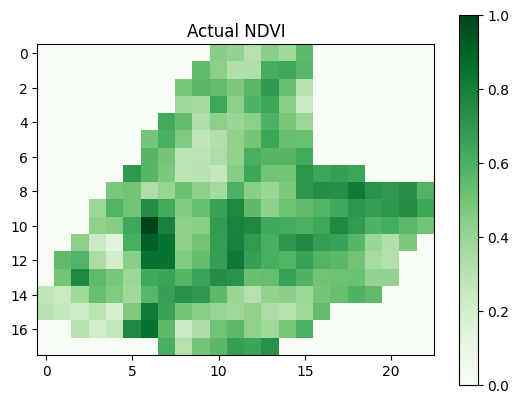

Step: 6
Predicted NDVI Greenery Percentage: 3.140096618357488 Actual NDVI  Greenery Percentage: 2.898550724637681


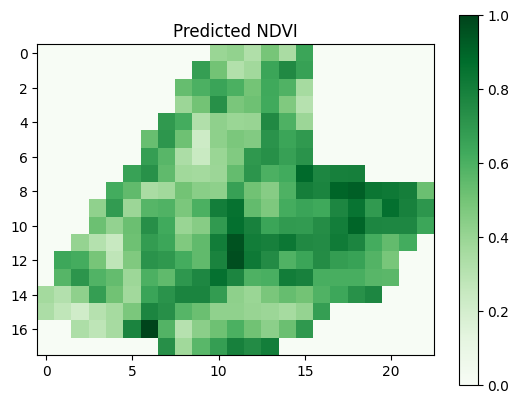

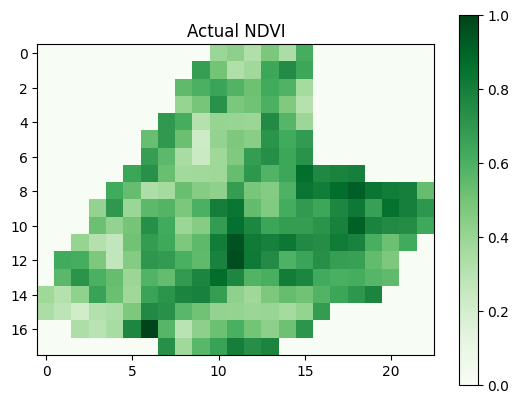

Step: 7
Predicted NDVI Greenery Percentage: 1.932367149758454 Actual NDVI  Greenery Percentage: 2.1739130434782608


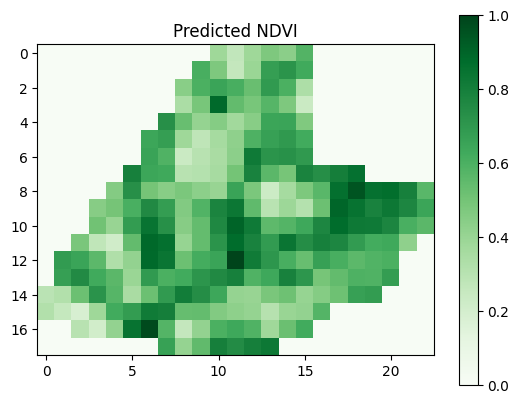

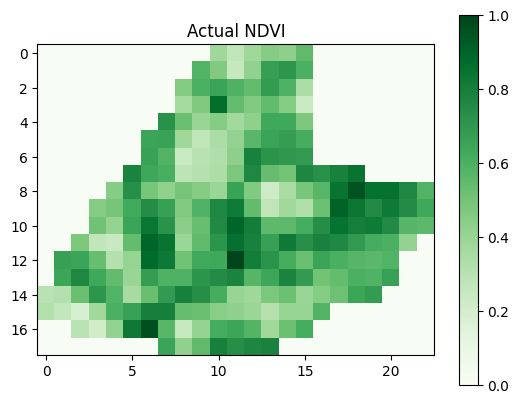

Step: 8
Predicted NDVI Greenery Percentage: 0.966183574879227 Actual NDVI  Greenery Percentage: 1.2077294685990339


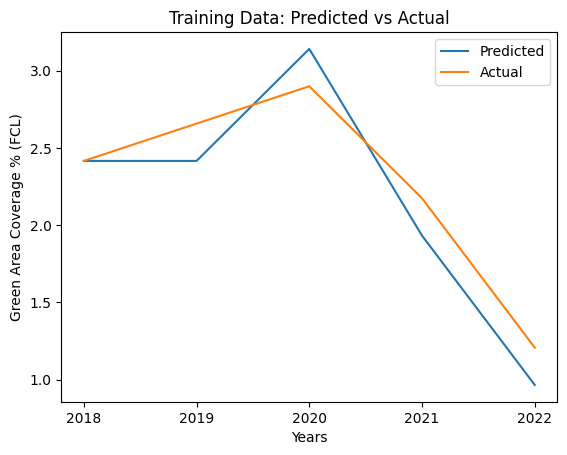

4
(6, 18, 23)


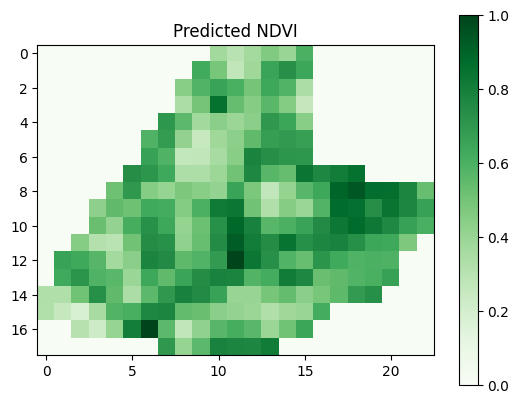

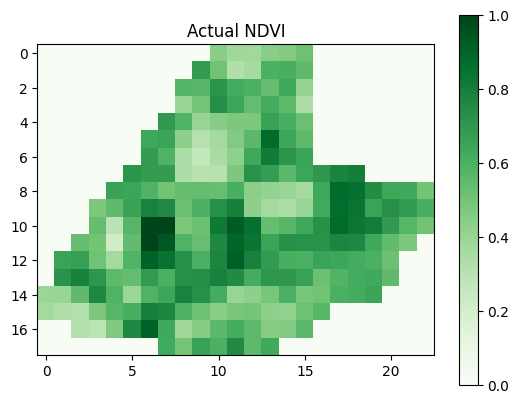

Step: 4
Predicted NDVI Greenery Percentage: 1.4492753623188406 Actual NDVI  Greenery Percentage: 1.2077294685990339


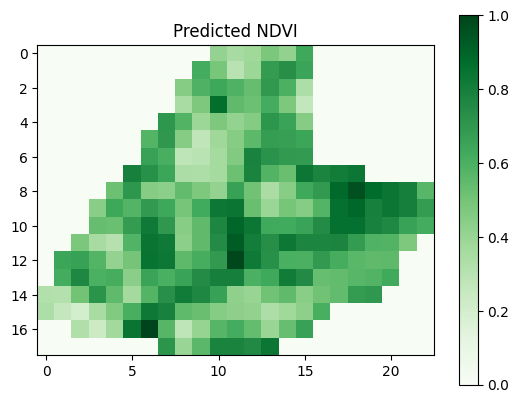

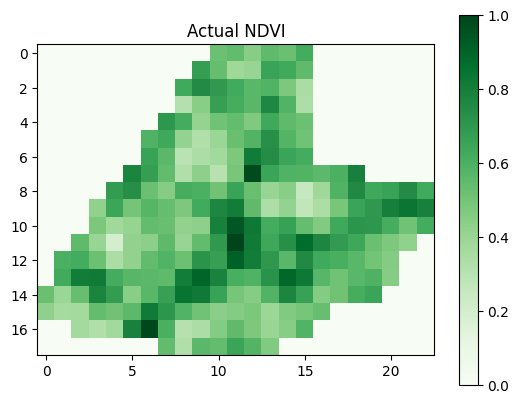

Step: 5
Predicted NDVI Greenery Percentage: 1.2077294685990339 Actual NDVI  Greenery Percentage: 0.966183574879227


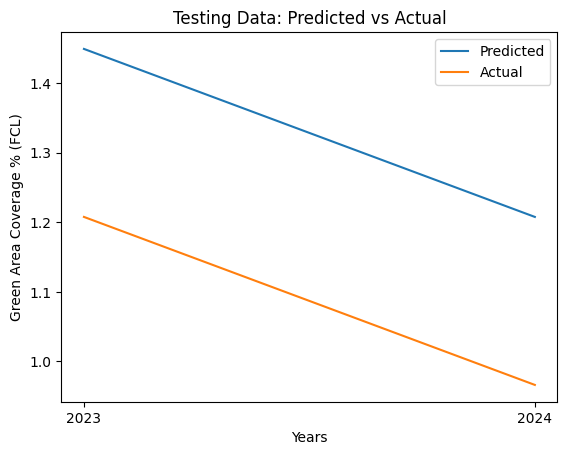

In [ ]:
from matplotlib import pyplot as plt

def calc_percent_greenery_by_fixed_coord(ndvi_mat, min_ndvi_coord = (10,11)):
    min_ndvi = ndvi_mat[min_ndvi_coord[0], min_ndvi_coord[1]]
    max_ndvi = np.max(ndvi_mat)
    count = 0
    for i in range(len(ndvi_mat)):
        for j in range(len(ndvi_mat[i])):
            if min_ndvi <= ndvi_mat[i, j] <= max_ndvi:
                count += 1

    total = len(ndvi_mat) * len(ndvi_mat[0])
    percent = count / total * 100
    return percent

def show_bw_image(img_gray, title=''):
    #show the grayscale image
    img_gray = img_gray/np.max(img_gray)
    plt.imshow(img_gray, cmap=plt.get_cmap('Greens'))
    plt.title(title)
    plt.colorbar()
    plt.show()


def plotData(data, years=[], heading='', skip_graph=False):
    pList = []
    aList = []
    steps = years
    if steps != []:
        append_steps = False
    else:
        append_steps = True
    print(lstm.lookback)
    print(data.shape)
    for s in range(lstm.lookback, len(data)):
        p = calc_percent_greenery_by_fixed_coord(lstm.forward(data[s - lstm.lookback: s]).detach().numpy().reshape(18, 23))
        a = calc_percent_greenery_by_fixed_coord(data[s].reshape(18,23))
        if not skip_graph:
            show_bw_image(lstm.forward(data[s - lstm.lookback: s]).detach().numpy().reshape(18, 23), "Predicted NDVI")
            show_bw_image(data[s].reshape(18,23), "Actual NDVI")
            print(f"Step: {s}")
            print(f"Predicted NDVI Greenery Percentage: {p} Actual NDVI  Greenery Percentage: {a}")
        pList.append(p)
        aList.append(a)
        if append_steps:
            steps.append(s)
    # for s in range(len(data)-lstm.lookback, 1, -1):
    #     p = calc_percent_greenery_by_fixed_coord(lstm(data[-s - lstm.lookback:-s])[0].detach().numpy().reshape(18, 23))
    #     a = calc_percent_greenery_by_fixed_coord(data[-s-lstm.lookback][0].numpy())
    #     print(f"Step: {len(data) - s}")
    #     print(f"Predicted NDVI Greenery Percentage: {p} Actual NDVI  Greenery Percentage: {a}")
    #     pList.append(p)
    #     aList.append(a)
    #     steps.append(len(data) - lstm.lookback - s + 1)
    plt.plot(steps, pList, label = "Predicted")
    plt.plot(steps, aList, label = 'Actual')
    plt.xlabel("Years")
    plt.ylabel("Green Area Coverage % (FCL)")
    plt.title(heading + 'Predicted vs Actual')
    plt.legend()
    plt.show()

plotData(dataTrain, ['2018', '2019', '2020', '2021', '2022'], "Training Data: ")
plotData(dataTest, ['2023', '2024'], "Testing Data: ")


4
(11, 18, 23)


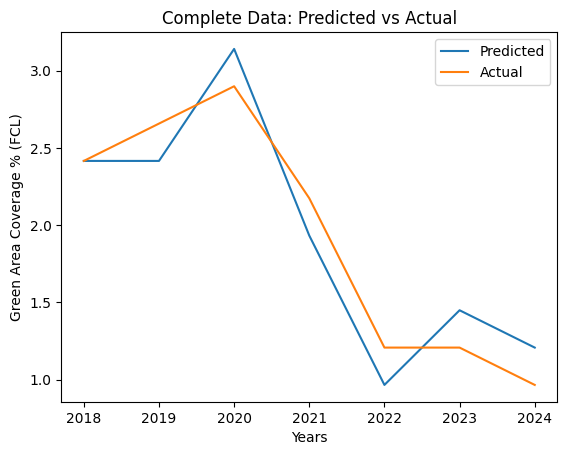

In [ ]:
plotData(data, ['2018', '2019', '2020', '2021', '2022', '2023', '2024'], 'Complete Data: ', True)

Fixed coordinate limits.svg

This is the graph of FCL for our complete data (2014 - 2024)

In [ ]:
import pickle

# Save the model
filename = 'trained_lstm_model.pkl'
pickle.dump(lstm, open(filename, 'wb'))

# Load the model
loaded_model = pickle.load(open(filename, 'rb'))